<a href="https://colab.research.google.com/github/virenmarcellya12/Analisis-Deret-Waktu/blob/main/tugas_kelompok_minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# menginstall package pydataset
!pip install pydataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

In [ ]:
suhu = pd.read_excel(
    'https://raw.githubusercontent.com/virenmarcellya12/Analisis-Deret-Waktu/refs/heads/main/suhu_di_kota_bandung.xlsx')

EKSPLORASI DATA

In [ ]:
#melihat struktur data
suhu.dtypes

,0
suhu,float64
tahun,datetime64[ns]


In [ ]:
# melihat 5 data pertama
suhu.head()

,suhu,tahun
0,24.2,2005-01-01
1,23.0,2005-02-01
2,23.3,2005-03-01
3,23.6,2005-04-01
4,23.9,2005-05-01


In [ ]:
#melihat 5 data terakhir
suhu.tail()

,suhu,tahun
247,33.4,2025-08-01
248,32.2,2025-09-01
249,36.0,2025-10-01
250,33.0,2025-11-01
251,32.8,2025-12-01


In [ ]:
#cek missing values
suhu.isnull().sum()

,0
suhu,0
tahun,0


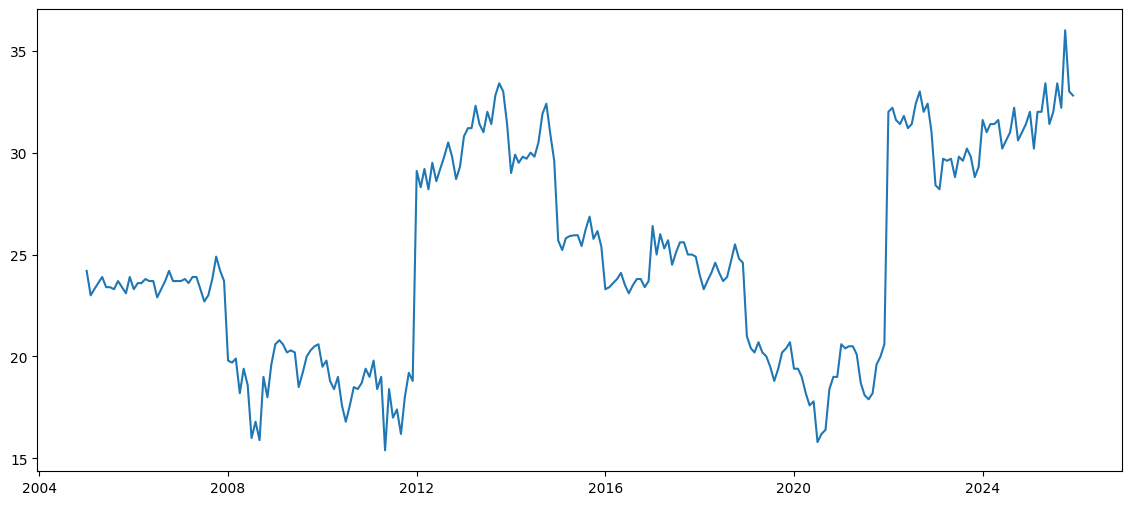

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(suhu['tahun'],suhu['suhu']); plt.show()

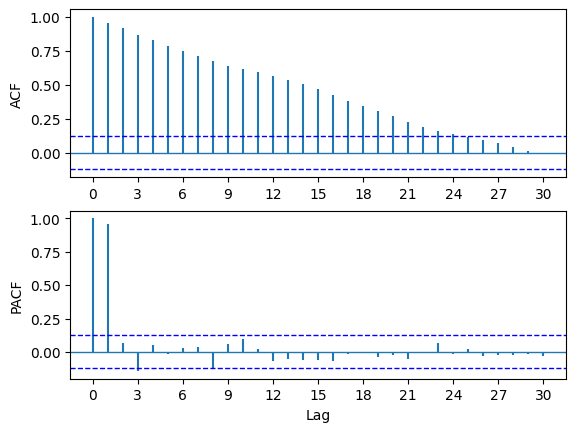

In [ ]:

# membuat plot ACF dan PACF contoh dari data nao
acf_pacf_fig(suhu['suhu'], both=True, lag=30)

CEK STASIONER DATA

In [ ]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(suhu['suhu'])[1]

0.2820770094308047

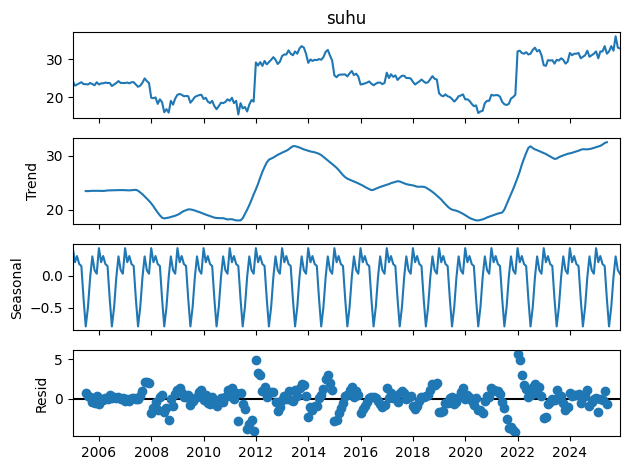

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
suhu2=suhu.set_index('tahun')
result = seasonal_decompose(suhu2['suhu'], model='additive')
result.plot()
plt.show()

In [ ]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(suhu['suhu'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.3339257369323398
interval kepercayaan lambda: (-0.318672205692964, 0.995352589824295)


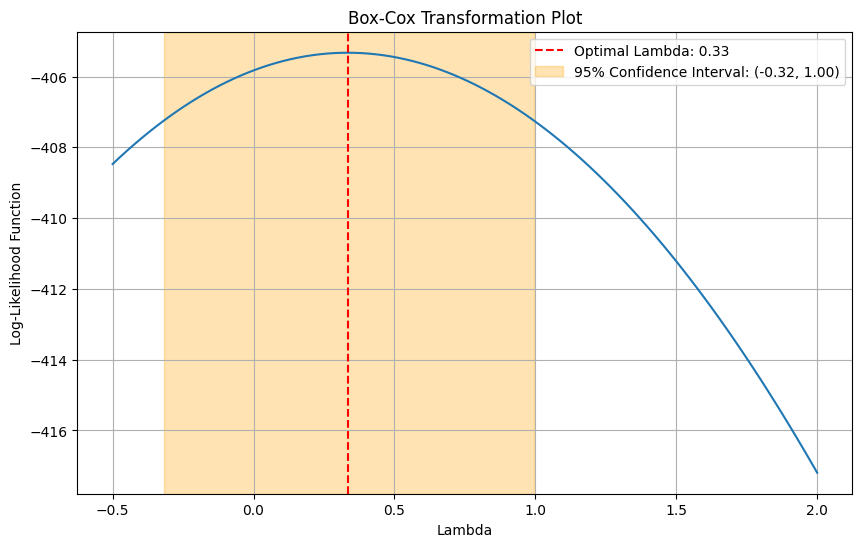

In [ ]:
import numpy as np
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, suhu['suhu']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

TRANSFORMASI BOX-COX

In [ ]:
from scipy.stats import boxcox

suhu['suhu_boxcox'], fitted_lambda = boxcox(suhu['suhu'])
print(f"Lambda optimal: {fitted_lambda}")

Lambda optimal: 0.3339257369323398


DIFFERENCING

In [ ]:
suhu['diff_boxcox'] = suhu['suhu_boxcox'].diff(1)

suhu_diff = suhu['diff_boxcox'].dropna()
suhu['diff_boxcox']

,diff_boxcox
0,NaN
1,-0.146141
2,0.037003
3,0.036687
4,0.036377
...,...
247,0.137203
248,-0.117361
249,0.362331
250,-0.283773


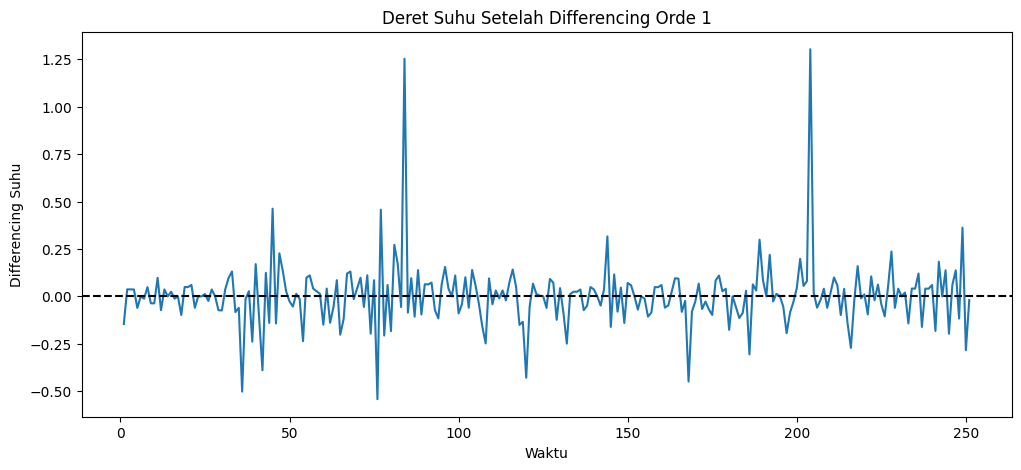

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(suhu_diff)
plt.axhline(0, color='black', linestyle='--')
plt.title('Deret Suhu Setelah Differencing Orde 1')
plt.xlabel('Waktu')
plt.ylabel('Differencing Suhu')
plt.show()

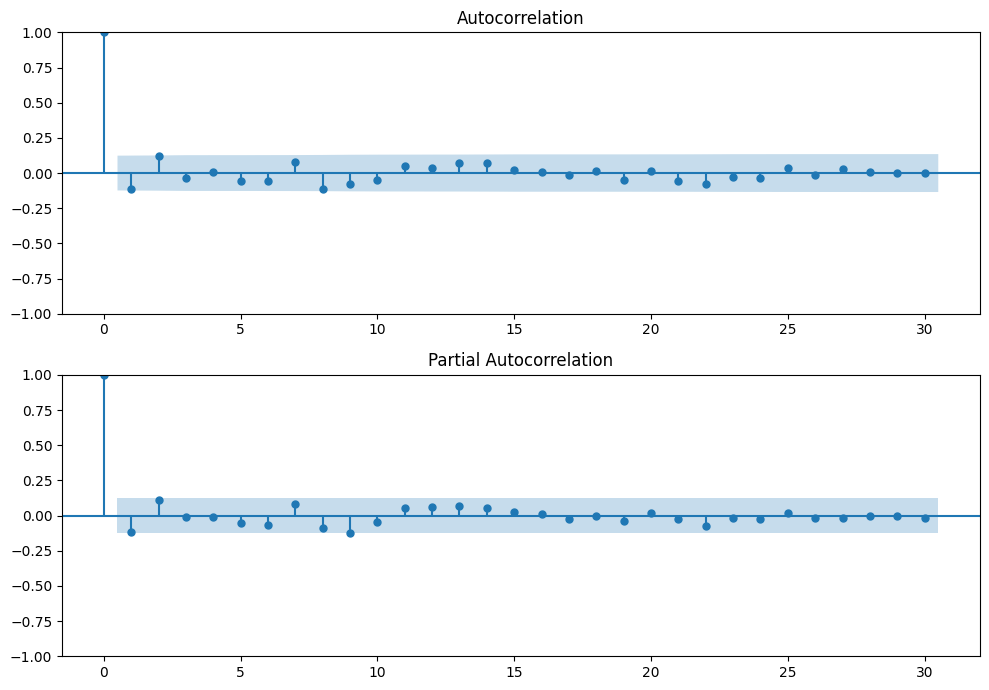

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(10,7))

plot_acf(suhu_diff, lags=30, ax=ax[0])
plot_pacf(suhu_diff, lags=30, ax=ax[1])

plt.tight_layout()
plt.show()